# Avance 2. Ingeniería de características

## Objetivos
2.3 Crear nuevas características para mejorar el rendimiento de los modelos.

2.4 Mitigar el riesgo de características sesgadas y acelerar la convergencia de algunos algoritmos.

## Librerías y Carga de Datos

### Librerías

In [1]:
import pandas as pd
import numpy as np
from tabulate import tabulate
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, f_classif
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import prince

### Carga de Datos

In [2]:
path = '../../data/processed/data2.parquet'
df = pd.read_parquet(path)
df.head()

,Año,Semana,Cuadro,Estado,Ax_001,Ax_002,Ax_003,Valor,Fecha,Codigo Padecimiento,Mes,Padecimiento
0,2014,2,CUADRO 17.,Aguascalientes,2014.0,0,Sem.,1.0,2014-01-06,F32,1,DepresiónCIE-10ª REV.F32
1,2014,2,CUADRO 17.,Quintana Roo,2014.0,Acum.,M,0.0,2014-01-06,F32,1,DepresiónCIE-10ª REV.F32
2,2014,2,CUADRO 17.,Quintana Roo,2014.0,Acum.,H,0.0,2014-01-06,F32,1,DepresiónCIE-10ª REV.F32
3,2014,2,CUADRO 17.,Quintana Roo,2014.0,0,Sem.,0.0,2014-01-06,F32,1,DepresiónCIE-10ª REV.F32
4,2014,2,CUADRO 17.,Querétaro,2014.0,Acum.,M,0.0,2014-01-06,F32,1,DepresiónCIE-10ª REV.F32


## Limpieza de Datos
Debido a que se cargó el dataset procesado del primer avance, los datos ya se encuentran limpios, sin embargo, como buena práctica y siguiendo la metodología CRISP-ML, nos aseguraremos de la limpieza

### Asegurar que la columna Fecha sea de tipo datetime
Convertir a datetime permite manipular y extraer información temporal (año, mes, semana, trimestre)
y detectar posibles valores no válidos (se convierten en NaT).

In [3]:
print(df['Fecha'].dtypes)

datetime64[ns]


### Estandarizar nombres de columnas
Estos nos permite unificar el formato de los nombres de columnas, facilitando su uso en código y evitando errores por inconsistencias.

In [4]:
df.columns = df.columns.str.strip()               # Elimina espacios al inicio o final
df.columns = df.columns.str.replace(' ', '_')     # Sustituye espacios por guiones bajos
df.columns = df.columns.str.lower()               # Convierte todo a minúsculas para consistencia

### Verificar valores nulos
Identificar valores faltantes es crucial para decidir si se imputan, eliminan o se dejan como NaN (según su relevancia o proporción).

In [5]:
print('\nValores faltantes por columna:')
print(tabulate(df.isnull().sum().reset_index(),
               headers=['Columna', 'Valores faltantes'],
               tablefmt='rounded_outline',
               showindex=False))


Valores faltantes por columna:
╭─────────────────────┬─────────────────────╮
│ Columna             │   Valores faltantes │
├─────────────────────┼─────────────────────┤
│ año                 │                   0 │
│ semana              │                   0 │
│ cuadro              │                   0 │
│ estado              │                   0 │
│ ax_001              │                1188 │
│ ax_002              │                1188 │
│ ax_003              │                   0 │
│ valor               │                1188 │
│ fecha               │                   0 │
│ codigo_padecimiento │                   0 │
│ mes                 │                   0 │
│ padecimiento        │                   0 │
╰─────────────────────┴─────────────────────╯


In [6]:
df['valor'] = df['valor'].fillna(0).astype(int)

Por la naturaleza de ax_001 y ax_002 existen algunos valores nulos, esto no debería afectar al análisis, ya que funcionan como filtros estas columnas

### Asegurar que 'valor' sea numérico
Forzamos a que 'valor' (número de casos) sea numérico. Si hay valores no convertibles (por error de digitación), se transforman en NaN para poder tratarlos más adelante.

In [7]:
print(df['valor'].dtypes)

int64


### Comprobación general del tipo de datos

In [8]:
print("\nTipos de datos después de la limpieza:")
print(df.dtypes)


Tipos de datos después de la limpieza:
año                             int64
semana                          int64
cuadro                         object
estado                         object
ax_001                        float64
ax_002                         object
ax_003                         object
valor                           int64
fecha                  datetime64[ns]
codigo_padecimiento            object
mes                             int32
padecimiento                   object
dtype: object


## Generación de nuevas características

Nota: en esta sección se esperaba agregar variables exógenas para mejorar el dataset y prepararlo para el futuro análisis, sin embargo, no se logró concretar una reunión de aprobación con la Dra. Ruth Pérez, líder de proyecto, por motivos de vacaciones laborales de la Dra. Es por esto, que a lo largo de este trabajo solo se trabajará con el dataset original, más la agregación de únicamente la variables exógenas que surgan del mismo dataset original.

### Fechas de pandemia por COVID-19
Para analizar el efecto de la pandemia sobre los diagnósticos de depresión.
* Categoría: 
  * Pre-Covid
  * Covid
  * Post-Covid

In [9]:
# Generar columna de temporada de COVID-19
# Rango de fechas de la pandemia en México
covid_start = pd.to_datetime('2020-03-01')
# covid_end = pd.to_datetime('2022-03-31')
covid_end = pd.to_datetime('2023-05-05')

df['periodo_covid'] = pd.cut(
    df['fecha'],
    bins=[pd.Timestamp.min, covid_start, 
          covid_end, pd.Timestamp.max],
    labels=['Pre-Covid', 'Covid', 'Post-Covid'],
    include_lowest=True
)
df.head()

,año,semana,cuadro,estado,ax_001,ax_002,ax_003,valor,fecha,codigo_padecimiento,mes,padecimiento,periodo_covid
0,2014,2,CUADRO 17.,Aguascalientes,2014.0,0,Sem.,1,2014-01-06,F32,1,DepresiónCIE-10ª REV.F32,Pre-Covid
1,2014,2,CUADRO 17.,Quintana Roo,2014.0,Acum.,M,0,2014-01-06,F32,1,DepresiónCIE-10ª REV.F32,Pre-Covid
2,2014,2,CUADRO 17.,Quintana Roo,2014.0,Acum.,H,0,2014-01-06,F32,1,DepresiónCIE-10ª REV.F32,Pre-Covid
3,2014,2,CUADRO 17.,Quintana Roo,2014.0,0,Sem.,0,2014-01-06,F32,1,DepresiónCIE-10ª REV.F32,Pre-Covid
4,2014,2,CUADRO 17.,Querétaro,2014.0,Acum.,M,0,2014-01-06,F32,1,DepresiónCIE-10ª REV.F32,Pre-Covid


### Temporada
Permite evaluar la influencia de factores climáticos o emocionales relacionados con las estaciones del año.

In [10]:
def asignar_temporada(mes):
    if mes in [12, 1, 2]:
        return 'Invierno'
    elif mes in [3, 4, 5]:
        return 'Primavera'
    elif mes in [6, 7, 8]:
        return 'Verano'
    else:
        return 'Otoño'

df['temporada'] = df['mes'].apply(asignar_temporada)

In [11]:
print('Dataset con nuevas características:')
df.head()

Dataset con nuevas características:


,año,semana,cuadro,estado,ax_001,ax_002,ax_003,valor,fecha,codigo_padecimiento,mes,padecimiento,periodo_covid,temporada
0,2014,2,CUADRO 17.,Aguascalientes,2014.0,0,Sem.,1,2014-01-06,F32,1,DepresiónCIE-10ª REV.F32,Pre-Covid,Invierno
1,2014,2,CUADRO 17.,Quintana Roo,2014.0,Acum.,M,0,2014-01-06,F32,1,DepresiónCIE-10ª REV.F32,Pre-Covid,Invierno
2,2014,2,CUADRO 17.,Quintana Roo,2014.0,Acum.,H,0,2014-01-06,F32,1,DepresiónCIE-10ª REV.F32,Pre-Covid,Invierno
3,2014,2,CUADRO 17.,Quintana Roo,2014.0,0,Sem.,0,2014-01-06,F32,1,DepresiónCIE-10ª REV.F32,Pre-Covid,Invierno
4,2014,2,CUADRO 17.,Querétaro,2014.0,Acum.,M,0,2014-01-06,F32,1,DepresiónCIE-10ª REV.F32,Pre-Covid,Invierno


### Trimestre y Semestre

Agregar una característica que indique el trimestre (Q1, Q2, Q3, Q4) o el semestre (S1, S2) ayuda al modelo a capturar patrones estacionales de mediano plazo.

In [12]:
df['trimestre'] = df['fecha'].dt.quarter
df['semestre'] = df['fecha'].dt.month.apply(lambda m: 1 if m <= 6 else 2)
df.head()

,año,semana,cuadro,estado,ax_001,ax_002,ax_003,valor,fecha,codigo_padecimiento,mes,padecimiento,periodo_covid,temporada,trimestre,semestre
0,2014,2,CUADRO 17.,Aguascalientes,2014.0,0,Sem.,1,2014-01-06,F32,1,DepresiónCIE-10ª REV.F32,Pre-Covid,Invierno,1,1
1,2014,2,CUADRO 17.,Quintana Roo,2014.0,Acum.,M,0,2014-01-06,F32,1,DepresiónCIE-10ª REV.F32,Pre-Covid,Invierno,1,1
2,2014,2,CUADRO 17.,Quintana Roo,2014.0,Acum.,H,0,2014-01-06,F32,1,DepresiónCIE-10ª REV.F32,Pre-Covid,Invierno,1,1
3,2014,2,CUADRO 17.,Quintana Roo,2014.0,0,Sem.,0,2014-01-06,F32,1,DepresiónCIE-10ª REV.F32,Pre-Covid,Invierno,1,1
4,2014,2,CUADRO 17.,Querétaro,2014.0,Acum.,M,0,2014-01-06,F32,1,DepresiónCIE-10ª REV.F32,Pre-Covid,Invierno,1,1


### Lags (Retrasos)
Los lags son las características más importantes a crear ya que le dan al modelo memoria y contexto sobre lo que ha ocurrido en el pasado, permitiéndole entender la inercia, la tendencia y los ciclos.

#### Lags a Corto Plazo (Inercia y Tendencia Reciente)
Estos lags le dicen al modelo lo que acaba de suceder y son cruciales para capturar el momentum de la serie.

Lags empleados: `t-1`, `t-2`, `t-3`, `t-4`, `t-6`.

Propósito:

* `t-1` (semana pasada): Suele ser el predictor más fuerte. Le dice al modelo que el valor de esta semana probablemente será muy similar al de la anterior.
* `t-4` (hace un mes): Resume la tendencia del último mes.
* `t-6` (hace mes y medio): Puede ayudar a capturar patrones que se extienden más allá de un solo mes.

#### Lags a Mediano Plazo (Ciclos Intermedios)
Estos lags pueden identificar tendencias que no son ni inmediatas ni anuales, como los ciclos de negocio.

* Lags empleados: `t-12` (hace un trimestre) y `t-26` (hace medio año).

* Propósito: Le dan al modelo una perspectiva más amplia para capturar cambios de tendencia que ocurren a lo largo de varios meses.

#### Lags Estacionales (El Patrón Anual)
Para datos semanales, este es el tipo de lag más importante y que no puede faltar.

* Lag empleado: `t-52` (la misma semana del año anterior).

* Propósito: Es fundamental para capturar la estacionalidad anual. Le dice al modelo: "Para predecir el comportamiento de esta semana, mira cómo se comportó la misma semana del año pasado". Esto captura el efecto de temporadas, vacaciones y cualquier otro patrón que se repita anualmente.

In [13]:
columnas_agrupadas = ["estado", "codigo_padecimiento", "ax_003"]
df.sort_values(by=columnas_agrupadas + ["fecha"], inplace=True)
lags = [1,2,3,4,6,12,26,52]
for lag in lags:
    df[f"valor_lag{lag}"] = df.groupby(columnas_agrupadas)["valor"].shift(lag).fillna(0).astype(int)
df.head()

,año,semana,cuadro,estado,ax_001,ax_002,ax_003,valor,fecha,codigo_padecimiento,...,trimestre,semestre,valor_lag1,valor_lag2,valor_lag3,valor_lag4,valor_lag6,valor_lag12,valor_lag26,valor_lag52
5332,2015,2,CUADRO 17.,Aguascalientes,2014.0,0,Acum.,1,2015-01-05,F32,...,1,1,0,0,0,0,0,0,0,0
5464,2015,3,CUADRO 17.,Aguascalientes,2014.0,0,Acum.,3,2015-01-12,F32,...,1,1,1,0,0,0,0,0,0,0
5595,2015,4,CUADRO 17.,Aguascalientes,2014.0,0,Acum.,4,2015-01-19,F32,...,1,1,3,1,0,0,0,0,0,0
5728,2015,5,CUADRO 17.,Aguascalientes,2014.0,0,Acum.,5,2015-01-26,F32,...,1,1,4,3,1,0,0,0,0,0
5861,2015,6,CUADRO 17.,Aguascalientes,2014.0,0,Acum.,7,2015-02-02,F32,...,1,1,5,4,3,1,0,0,0,0


### Discretización (binning) de 'valor' en niveles bajo, medio y alto 
Agrupa los casos en categorías ordinales, útil para modelos interpretativos o análisis de tendencia.

In [14]:
df_nonzero = df[df['valor'] > 0]
df.loc[df['valor'] > 0, 'valor_cat'] = pd.qcut(df_nonzero['valor'], q=3, labels=['bajo', 'medio', 'alto'], duplicates='drop')
df.loc[df['valor'] == 0, 'valor_cat'] = 'bajo'

In [15]:
print('Dataset con nueva discretización:')
df.head()

Dataset con nueva discretización:


,año,semana,cuadro,estado,ax_001,ax_002,ax_003,valor,fecha,codigo_padecimiento,...,semestre,valor_lag1,valor_lag2,valor_lag3,valor_lag4,valor_lag6,valor_lag12,valor_lag26,valor_lag52,valor_cat
5332,2015,2,CUADRO 17.,Aguascalientes,2014.0,0,Acum.,1,2015-01-05,F32,...,1,0,0,0,0,0,0,0,0,bajo
5464,2015,3,CUADRO 17.,Aguascalientes,2014.0,0,Acum.,3,2015-01-12,F32,...,1,1,0,0,0,0,0,0,0,bajo
5595,2015,4,CUADRO 17.,Aguascalientes,2014.0,0,Acum.,4,2015-01-19,F32,...,1,3,1,0,0,0,0,0,0,bajo
5728,2015,5,CUADRO 17.,Aguascalientes,2014.0,0,Acum.,5,2015-01-26,F32,...,1,4,3,1,0,0,0,0,0,bajo
5861,2015,6,CUADRO 17.,Aguascalientes,2014.0,0,Acum.,7,2015-02-02,F32,...,1,5,4,3,1,0,0,0,0,bajo


### Codificación

#### Codificación ordinal para variables con orden lógico
Se aplica codificación ordinal porque existe una jerarquía natural entre las categorías

In [16]:
# valor_cat
ordinal_vars = ['valor_cat']
encoder_ordinal = OrdinalEncoder()

df[ordinal_vars] = encoder_ordinal.fit_transform(df[ordinal_vars])

#### Codificación one-hot para variables nominales (sin orden)
La codificación one-hot convierte categorías no ordenadas en variables binarias (dummy variables),
evitando que el modelo interprete jerarquías inexistentes y reduciendo colinealidad con drop_first=True.

In [17]:
nominal_vars = ['estado', 'temporada', 'codigo_padecimiento','periodo_covid','cuadro']
dummies = pd.get_dummies(df[nominal_vars], drop_first=True)
df = df.join(dummies)
df.drop(columns=nominal_vars, inplace=True)

In [18]:
print('Dataset con nueva codificaciones:')
df.head()

Dataset con nueva codificaciones:


,año,semana,ax_001,ax_002,ax_003,valor,fecha,mes,padecimiento,trimestre,...,codigo_padecimiento_X70,codigo_padecimiento_X72,codigo_padecimiento_X78,codigo_padecimiento_X80,codigo_padecimiento_Z91.5,periodo_covid_Covid,periodo_covid_Post-Covid,cuadro_CUADRO 17.1,cuadro_CUADRO 17.2,cuadro_CUADRO 17.3
5332,2015,2,2014.0,0,Acum.,1,2015-01-05,1,DepresiónCIE-10ª REV.F32,1,...,False,False,False,False,False,False,False,False,False,False
5464,2015,3,2014.0,0,Acum.,3,2015-01-12,1,DepresiónCIE-10ª REV.F32,1,...,False,False,False,False,False,False,False,False,False,False
5595,2015,4,2014.0,0,Acum.,4,2015-01-19,1,DepresiónCIE-10ª REV.F32,1,...,False,False,False,False,False,False,False,False,False,False
5728,2015,5,2014.0,0,Acum.,5,2015-01-26,1,DepresiónCIE-10ª REV.F32,1,...,False,False,False,False,False,False,False,False,False,False
5861,2015,6,2014.0,0,Acum.,7,2015-02-02,2,DepresiónCIE-10ª REV.F32,1,...,False,False,False,False,False,False,False,False,False,False


#### Escalamiento (normalización, estandarización, min – max,…)

In [19]:
scaler_minmax = MinMaxScaler()
df[['valor_minmax']] = scaler_minmax.fit_transform(df[['valor']])

In [20]:
print('Dataset con escalamiento:')
df.head()

Dataset con escalamiento:


,año,semana,ax_001,ax_002,ax_003,valor,fecha,mes,padecimiento,trimestre,...,codigo_padecimiento_X72,codigo_padecimiento_X78,codigo_padecimiento_X80,codigo_padecimiento_Z91.5,periodo_covid_Covid,periodo_covid_Post-Covid,cuadro_CUADRO 17.1,cuadro_CUADRO 17.2,cuadro_CUADRO 17.3,valor_minmax
5332,2015,2,2014.0,0,Acum.,1,2015-01-05,1,DepresiónCIE-10ª REV.F32,1,...,False,False,False,False,False,False,False,False,False,0.000006
5464,2015,3,2014.0,0,Acum.,3,2015-01-12,1,DepresiónCIE-10ª REV.F32,1,...,False,False,False,False,False,False,False,False,False,0.000019
5595,2015,4,2014.0,0,Acum.,4,2015-01-19,1,DepresiónCIE-10ª REV.F32,1,...,False,False,False,False,False,False,False,False,False,0.000026
5728,2015,5,2014.0,0,Acum.,5,2015-01-26,1,DepresiónCIE-10ª REV.F32,1,...,False,False,False,False,False,False,False,False,False,0.000032
5861,2015,6,2014.0,0,Acum.,7,2015-02-02,2,DepresiónCIE-10ª REV.F32,1,...,False,False,False,False,False,False,False,False,False,0.000045


#### Transformación (logarítmica, exponencial, raíz cuadrada, Box – Cox, Yeo – Johnson,…)

La transformación Yeo–Johnson es adecuada para valores positivos y negativos, y corrige asimetrías sin requerir logaritmos, lo que mejora el rendimiento de modelos sensibles a la normalidad.

In [21]:
# Transformación de potencia (Yeo–Johnson) para normalizar distribución
pt = PowerTransformer(method='yeo-johnson')
df[['valor_yeojohnson']] = pt.fit_transform(df[['valor']])

In [22]:
print('Dataset con transformación Yeo-Johnson:')
df.head()

Dataset con transformación Yeo-Johnson:


,año,semana,ax_001,ax_002,ax_003,valor,fecha,mes,padecimiento,trimestre,...,codigo_padecimiento_X78,codigo_padecimiento_X80,codigo_padecimiento_Z91.5,periodo_covid_Covid,periodo_covid_Post-Covid,cuadro_CUADRO 17.1,cuadro_CUADRO 17.2,cuadro_CUADRO 17.3,valor_minmax,valor_yeojohnson
5332,2015,2,2014.0,0,Acum.,1,2015-01-05,1,DepresiónCIE-10ª REV.F32,1,...,False,False,False,False,False,False,False,False,0.000006,-0.996871
5464,2015,3,2014.0,0,Acum.,3,2015-01-12,1,DepresiónCIE-10ª REV.F32,1,...,False,False,False,False,False,False,False,False,0.000019,-0.608798
5595,2015,4,2014.0,0,Acum.,4,2015-01-19,1,DepresiónCIE-10ª REV.F32,1,...,False,False,False,False,False,False,False,False,0.000026,-0.490634
5728,2015,5,2014.0,0,Acum.,5,2015-01-26,1,DepresiónCIE-10ª REV.F32,1,...,False,False,False,False,False,False,False,False,0.000032,-0.396428
5861,2015,6,2014.0,0,Acum.,7,2015-02-02,2,DepresiónCIE-10ª REV.F32,1,...,False,False,False,False,False,False,False,False,0.000045,-0.251945


### Estandarizar nombres de columnas

In [23]:
df.columns = df.columns.str.strip()               # Elimina espacios al inicio o final
df.columns = df.columns.str.replace(' ', '_')     # Sustituye espacios por guiones bajos
df.columns = df.columns.str.lower()              # Convierte todo a minúsculas para consistencia
df.columns = df.columns.str.replace('cuadro_cuadro_', 'cuadro_', n=1) # Simplifica nombres de columnas
df.columns = df.columns.str.replace('_covid_', '_', n=1) # Simplifica nombres de columnas

## Selección y extracción de características


#### Eliminación de columnas no necesarias
Después de las transformaciones, escalamientos y codificaciones, podemos eliminar algunas columnas que ya no serán necesarias para el análisis

In [24]:
# df_analysis = df.drop(columns=['padecimiento', 'valor_cat'])
df_analysis = df.drop(columns=['padecimiento', 'valor_cat'])
df_analysis.head()

,año,semana,ax_001,ax_002,ax_003,valor,fecha,mes,trimestre,semestre,...,codigo_padecimiento_x78,codigo_padecimiento_x80,codigo_padecimiento_z91.5,periodo_covid,periodo_post-covid,cuadro_17.1,cuadro_17.2,cuadro_17.3,valor_minmax,valor_yeojohnson
5332,2015,2,2014.0,0,Acum.,1,2015-01-05,1,1,1,...,False,False,False,False,False,False,False,False,0.000006,-0.996871
5464,2015,3,2014.0,0,Acum.,3,2015-01-12,1,1,1,...,False,False,False,False,False,False,False,False,0.000019,-0.608798
5595,2015,4,2014.0,0,Acum.,4,2015-01-19,1,1,1,...,False,False,False,False,False,False,False,False,0.000026,-0.490634
5728,2015,5,2014.0,0,Acum.,5,2015-01-26,1,1,1,...,False,False,False,False,False,False,False,False,0.000032,-0.396428
5861,2015,6,2014.0,0,Acum.,7,2015-02-02,2,1,1,...,False,False,False,False,False,False,False,False,0.000045,-0.251945


In [25]:
print(f'Nombres de columnas estandarizados:')
print(*[f"- {col}" for col in df_analysis.columns], sep="\n")


Nombres de columnas estandarizados:
- año
- semana
- ax_001
- ax_002
- ax_003
- valor
- fecha
- mes
- trimestre
- semestre
- valor_lag1
- valor_lag2
- valor_lag3
- valor_lag4
- valor_lag6
- valor_lag12
- valor_lag26
- valor_lag52
- estado_baja_california
- estado_baja_california_sur
- estado_campeche
- estado_chiapas
- estado_chihuahua
- estado_ciudad_de_méxico
- estado_coahuila
- estado_colima
- estado_distrito_federal
- estado_durango
- estado_guanajuato
- estado_guerrero
- estado_hidalgo
- estado_jalisco
- estado_michoacán
- estado_morelos
- estado_méxico
- estado_nayarit
- estado_nuevo_león
- estado_oaxaca
- estado_puebla
- estado_querétaro
- estado_quintana_roo
- estado_san_luis_potosí
- estado_sinaloa
- estado_sonora
- estado_total
- estado_tabasco
- estado_tamaulipas
- estado_tlaxcala
- estado_veracruz
- estado_yucatán
- estado_zacatecas
- temporada_otoño
- temporada_primavera
- temporada_verano
- codigo_padecimiento_g20
- codigo_padecimiento_g30
- codigo_padecimiento_r45.8
- co

### Extracción de características

#### Justificación de la Estrategia de Extracción de Características

##### Limitaciones de las Técnicas Clásicas

Las estrategias tradicionales de extracción de características **no son adecuadas** para aplicarse de manera general a nuestro dataset debido a:

1. **Naturaleza Heterogénea de los Datos**:
   - Variables categóricas administrativas (estados, códigos de padecimiento)
   - Variables binarias (dummies) sin correlación lineal
   - Variables temporales con diferentes escalas y significados

2. **Baja Correlación Entre Grupos de Variables**:
   - Las variables categóricas no tienen relaciones numéricas entre sí
   - Los lags temporales forman un grupo cohesivo, pero no se correlacionan con las dummies
   - Aplicar PCA global diluiría la información temporal específica

3. **Preservación del Significado**:
   - Las variables dummy representan información categórica que no debe mezclarse
   - Los lags capturan patrones temporales que requieren análisis especializado

##### Estrategia Adoptada: PCA por Grupos Homogéneos

Implementaremos **Análisis de Componentes Principales (PCA) selectivo** únicamente en grupos de variables que comparten características similares:

**Grupo Target: Variables de Valor Lag**
- `valor_lag1`, `valor_lag2`, `valor_lag3`, `valor_lag4`, `valor_lag6`, `valor_lag12`, `valor_lag26`, `valor_lag52`
- **Justificación**: Todas representan la misma métrica (número de casos) en diferentes períodos temporales
- **Objetivo**: Reducir redundancia entre lags correlacionados manteniendo la información temporal esencial
- **Beneficio**: Captura patrones temporales complejos en menos dimensiones sin perder interpretabilidad

**Variables Excluidas del PCA**:
- Variables dummy (estados, temporadas, códigos): Mantienen su interpretabilidad categórica
- Variables transformadas individuales: Cada una tiene un propósito específico
- Variables temporales básicas: Conservan su significado directo

##### Ventajas de esta Aproximación

1. **Interpretabilidad**: Las variables categóricas mantienen su significado original
2. **Eficiencia**: Reduce dimensionalidad solo donde es beneficioso
3. **Precisión**: Evita mezclar información de diferentes naturalezas
4. **Flexibilidad**: Permite análisis específicos por tipo de variable

--- Varianza Acumulada por Componente ---
1 componentes explican: 85.15% de la varianza
2 componentes explican: 92.44% de la varianza
3 componentes explican: 96.17% de la varianza
4 componentes explican: 98.02% de la varianza
5 componentes explican: 98.96% de la varianza
6 componentes explican: 99.47% de la varianza
7 componentes explican: 99.76% de la varianza
8 componentes explican: 100.00% de la varianza
Para alcanzar al menos el 95% de la varianza, necesitas: 3 componentes.


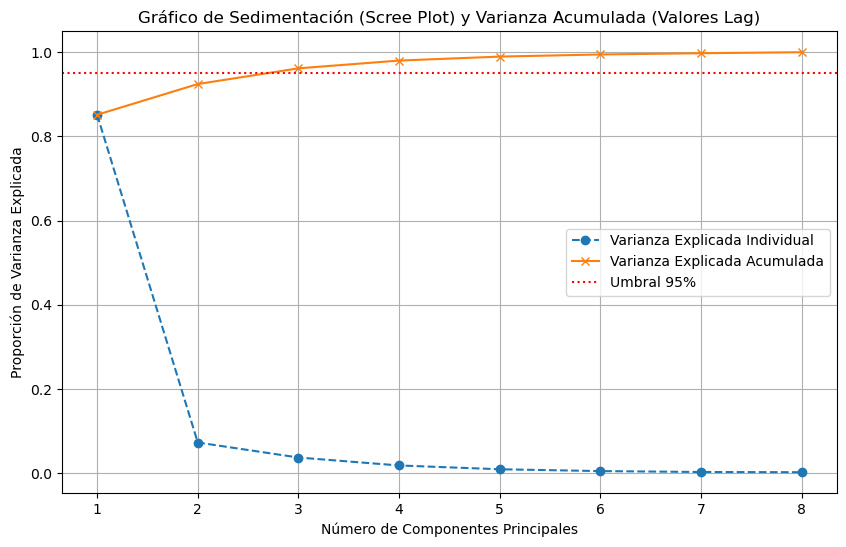

In [26]:
df_analysis_filtered = df.loc[:, df.columns.str.startswith('valor_lag')]

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_analysis_filtered)

pca = PCA()
pca.fit(df_scaled)

umbral = 0.95

# Calcular la varianza acumulada explicada
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

print("--- Varianza Acumulada por Componente ---")
for i, val in enumerate(varianza_acumulada):
    print(f"{i+1} componentes explican: {val:.2%} de la varianza")

maximos_componentes = len(df_analysis_filtered.columns)

# np.argmax encuentra el índice del primer 'True'
# Le sumamos 1 porque los índices empiezan en 0
n_componentes_optimo = np.argmax(varianza_acumulada >= umbral) + 1

print(f"Para alcanzar al menos el {umbral:.0%} de la varianza, necesitas: {n_componentes_optimo} componentes.")

# Graficar el Scree Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, maximos_componentes + 1), pca.explained_variance_ratio_, marker='o', linestyle='--', label='Varianza Explicada Individual')
plt.plot(range(1, maximos_componentes + 1), varianza_acumulada, marker='x', linestyle='-', label='Varianza Explicada Acumulada')

# Línea para el umbral del 95%
plt.axhline(y=umbral, color='r', linestyle=':', label=f'Umbral {umbral:.0%}')

plt.title('Gráfico de Sedimentación (Scree Plot) y Varianza Acumulada (Valores Lag)')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Proporción de Varianza Explicada')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
pca_final = PCA(n_components=n_componentes_optimo)
componentes_principales = pca_final.fit_transform(df_scaled)
df_pca = pd.DataFrame(componentes_principales, columns=[f'valor_lagPC{i+1}' for i in range(n_componentes_optimo)])

df_final = pd.concat([df_analysis.reset_index(drop=True), df_pca.reset_index(drop=True)], axis=1)
df_final.drop(columns=df_analysis_filtered.columns, inplace=True)
df_final.head()

,año,semana,ax_001,ax_002,ax_003,valor,fecha,mes,trimestre,semestre,...,periodo_covid,periodo_post-covid,cuadro_17.1,cuadro_17.2,cuadro_17.3,valor_minmax,valor_yeojohnson,valor_lagPC1,valor_lagPC2,valor_lagPC3
0,2015,2,2014.0,0,Acum.,1,2015-01-05,1,1,1,...,False,False,False,False,False,0.000006,-0.996871,-0.332540,-0.026225,0.002363
1,2015,3,2014.0,0,Acum.,3,2015-01-12,1,1,1,...,False,False,False,False,False,0.000019,-0.608798,-0.332437,-0.026284,0.002296
2,2015,4,2014.0,0,Acum.,4,2015-01-19,1,1,1,...,False,False,False,False,False,0.000026,-0.490634,-0.332126,-0.026460,0.002125
3,2015,5,2014.0,0,Acum.,5,2015-01-26,1,1,1,...,False,False,False,False,False,0.000032,-0.396428,-0.331709,-0.026685,0.001985
4,2015,6,2014.0,0,Acum.,7,2015-02-02,2,1,1,...,False,False,False,False,False,0.000045,-0.251945,-0.331185,-0.026944,0.001920


In [28]:
# # Guarda el df_analysis en un archivo parquet
# df_analysis.to_parquet('../../data/interim/data.parquet')
# print(f'DataFrame guardado exitosamente con {len(df_analysis):,} registros')
# print(f'Archivo guardado en: ../../data/interim/data.parquet')

## Conclusiones

Durante la fase de Preparación de los datos e Ingeniería de Características, correspondiente a la metodología CRISP-ML, se realizó un proceso exhaustivo para transformar el conjunto de datos crudo en un dataset robusto, enriquecido y optimizado para el modelado predictivo. Este proceso fue fundamental para asegurar la calidad de la información y para crear nuevas variables con alto potencial explicativo.

El trabajo se puede resumir en los siguientes puntos clave:

1. Limpieza y Estandarización: Se partió de una base de datos ya procesada, sobre la cual se aplicaron buenas prácticas para confirmar su integridad. Esto incluyó la estandarización de los nombres de las columnas, la verificación de tipos de datos y la imputación estratégica de valores nulos en la columna valor, reconociendo que la nulidad en otras columnas como ax_001 y ax_002 es inherente a su función como filtros.

2. Creación de Características Temporales y Contextuales: Ante la imposibilidad de añadir variables exógenas externas, el esfuerzo se centró en derivar características valiosas a partir de los datos existentes. Se generaron variables clave para capturar patrones temporales y contextuales, tales como:

   * Periodo COVID: Una variable categórica (Pre-Covid, Covid, Post-Covid) para modelar el impacto de la pandemia.

   * Estacionalidad: Creación de variables como temporada, trimestre y semestre para capturar ciclos anuales.

   * Variables de Rezagos (Lags): Se implementó la técnica más importante para el análisis de series temporales, creando lags a corto, mediano y largo plazo (t-1, t-4, t-52, etc.). Esto dota al modelo de "memoria", permitiéndole entender la inercia, las tendencias y la estacionalidad anual de los datos.

3. Transformación y Codificación de Datos: Para preparar los datos para los algoritmos de machine learning, se aplicaron diversas técnicas:

   * Codificación: Las variables categóricas fueron tratadas adecuadamente mediante codificación ordinal (valor_cat) y one-hot (estado, temporada, etc.), evitando la introducción de jerarquías falsas.

   * Escalamiento y Transformación: Se normalizó la variable valor usando MinMaxScaler y se corrigió su asimetría con una transformación de potencia Yeo-Johnson, mejorando la compatibilidad con modelos sensibles a la distribución de los datos.

4. Extracción de Características y Reducción de Dimensionalidad: A diferencia de una conclusión inicial que sugería que la reducción de dimensionalidad no era viable, se adoptó un enfoque más sofisticado y efectivo. Se reconoció correctamente que aplicar PCA globalmente sería inadecuado debido a la heterogeneidad de los datos. En su lugar, se aplicó Análisis de Componentes Principales (PCA) de forma selectiva únicamente al grupo homogéneo de las variables de rezago. Esta estrategia permitió reducir la dimensionalidad de 8 variables de lag a solo 3 componentes principales, conservando más del 95% de la varianza original y encapsulando de manera eficiente la información temporal compleja.

En resumen, esta fase no solo depuró y estructuró los datos, sino que los enriqueció significativamente mediante una ingeniería de características bien justificada. El resultado es un conjunto de datos de alta calidad, listo para la fase de modelado, y que demuestra un entendimiento profundo de las técnicas necesarias para el tratamiento de series temporales en el contexto de la salud pública.